In [1]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 

# data (as pandas dataframes) 
X = banknote_authentication.data.features 
y = banknote_authentication.data.targets 

# metadata 
print(banknote_authentication.metadata) 

# variable information 
print(banknote_authentication.variables)

print(X.head())
print(y.head())

{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=598, 
    stratify=y
)

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import zero_one_loss

linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

linreg_y_pred = linreg_model.predict(X_test)
linreg_y_pred_bin = np.where(linreg_y_pred >= 0.5, 1, 0)
linreg_misclass_rate = zero_one_loss(y_test, linreg_y_pred_bin)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn_y_preds = []
knn_misclass_rate = []
for k in range(1, 21):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train.squeeze())
    
    y_preds = knn_model.predict(X_test)
    knn_y_preds.append(y_preds)

    misclass_rate = zero_one_loss(y_test, y_preds)
    knn_misclass_rate.append(misclass_rate)

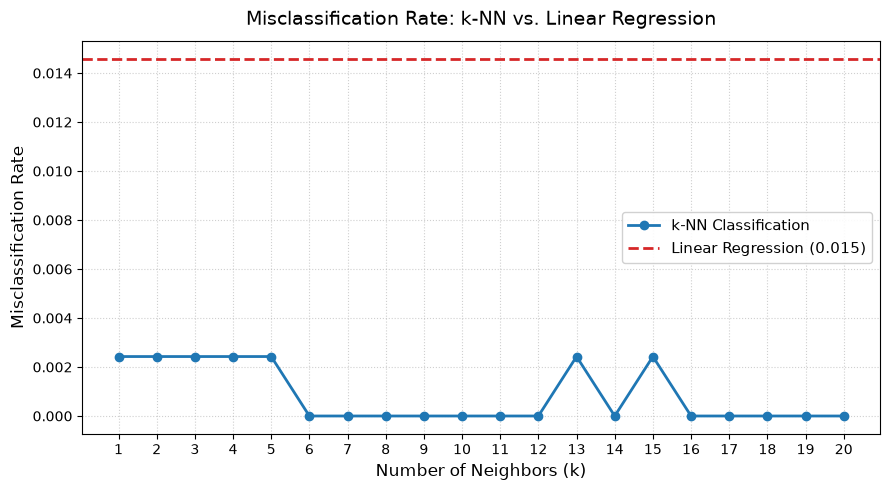

In [5]:
import matplotlib.pyplot as plt

k_values = list(range(1, 21))

plt.figure(figsize=(9, 5), dpi=100)

# Plot KNN Misclassification Rate
plt.plot(
    k_values, 
    knn_misclass_rate, 
    marker='o', 
    linewidth=2, 
    color='#1f77b4', 
    label='k-NN Classification'
)

# Plot Linear Regression Misclassification Rate (Horizontal Baseline)
plt.axhline(
    y=linreg_misclass_rate, 
    color='#d62728', 
    linestyle='--', 
    linewidth=2, 
    label=f'Linear Regression ({linreg_misclass_rate:.3f})'
)

# Formatting and Labels
plt.title('Misclassification Rate: k-NN vs. Linear Regression', fontsize=14, pad=12)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Misclassification Rate', fontsize=12)
plt.xticks(k_values)  # Show integer ticks for every k

# Grid, Legend, and Layout Cleanups
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()

plt.show()